# Story 1: Schema Builder

In [2]:
# Load and join Orders, Reviews, and Customers tables

import pandas as pd

# Load the three main datasets
orders = pd.read_csv("../data/olist_orders_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")

print("Orders shape:", orders.shape)
print("Reviews shape:", reviews.shape)
print("Customers shape:", customers.shape)


Orders shape: (99441, 8)
Reviews shape: (99224, 7)
Customers shape: (99441, 5)


In [44]:
# Check for duplicate keys before joining
print("Orders -> unique order_id:", orders["order_id"].nunique())
print("Orders -> total rows:", len(orders))
print()
print("Reviews -> unique order_id:", reviews["order_id"].nunique())
print("Reviews -> total rows:", len(reviews))
print("Reviews -> duplicate order_ids:", reviews["order_id"].duplicated().sum())
print()
print("Customers -> unique customer_id:", customers["customer_id"].nunique())
print("Customers -> total rows:", len(customers))

Orders -> unique order_id: 99441
Orders -> total rows: 99441

Reviews -> unique order_id: 98673
Reviews -> total rows: 99224
Reviews -> duplicate order_ids: 551

Customers -> unique customer_id: 99441
Customers -> total rows: 99441


In [6]:
# Some orders have multiple reviews, so we take the average
reviews_clean = reviews.groupby("order_id", as_index=False)["review_score"].mean()
reviews_clean["review_score"] = reviews_clean["review_score"].round(2)

print("Clean reviews shape:", reviews_clean.shape)
print("Clean reviews -> unique order_id:", reviews_clean["order_id"].nunique())
print("\nSample of clean reviews:")
print(reviews_clean.head())

Clean reviews shape: (98673, 2)
Clean reviews -> unique order_id: 98673

Sample of clean reviews:
                           order_id  review_score
0  00010242fe8c5a6d1ba2dd792cb16214           5.0
1  00018f77f2f0320c557190d7a144bdd3           4.0
2  000229ec398224ef6ca0657da4fc703e           5.0
3  00024acbcdf0a6daa1e931b038114c75           4.0
4  00042b26cf59d7ce69dfabb4e55b4fd9           5.0


In [7]:
# Build the master dataset
# Join orders with customers, then with reviews
master = orders.merge(customers, on="customer_id", how="left")
master = master.merge(reviews_clean, on="order_id", how="left")

print("Master dataset shape:", master.shape)
print("Master - unique order_id:", master["order_id"].nunique())

# Verify no duplicate rows
if len(master) == master["order_id"].nunique():
    print("Success: One row per order (no duplicates)")
else:
    print("Warning: Duplicate order rows detected")

print("\nMaster dataset preview:")
print(master.head())


Master dataset shape: (99441, 13)
Master - unique order_id: 99441
Success: One row per order (no duplicates)

Master dataset preview:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_deliv

In [8]:
# Step 5: Check the final dataset
print("Master dataset columns:")
print(master.columns.tolist())
print("\nMissing values per column:")
print(master.isnull().sum())

Master dataset columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score']

Missing values per column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
review_score                      768
dtype: int64


# Story 2: The Delay Calculator

In [11]:
# Calculate delivery delays and classify orders

# Convert date columns to datetime
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'])
master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'])


print(master[['order_delivered_customer_date', 'order_estimated_delivery_date']].head())


  order_delivered_customer_date order_estimated_delivery_date
0           2017-10-10 21:25:13                    2017-10-18
1           2018-08-07 15:27:45                    2018-08-13
2           2018-08-17 18:06:29                    2018-09-04
3           2017-12-02 00:28:42                    2017-12-15
4           2018-02-16 18:17:02                    2018-02-26


In [12]:
# Calculate the difference in days
# Positive = delivered early, Negative = delivered late
master['Days_Difference'] = (master['order_estimated_delivery_date'] - master['order_delivered_customer_date']).dt.days

print(master[['order_delivered_customer_date', 'order_estimated_delivery_date', 'Days_Difference']].head())


  order_delivered_customer_date order_estimated_delivery_date  Days_Difference
0           2017-10-10 21:25:13                    2017-10-18              7.0
1           2018-08-07 15:27:45                    2018-08-13              5.0
2           2018-08-17 18:06:29                    2018-09-04             17.0
3           2017-12-02 00:28:42                    2017-12-15             12.0
4           2018-02-16 18:17:02                    2018-02-26              9.0


In [13]:
# Classify delivery status
master['Delivery_Status'] = 'On Time'  # Start with everyone as "On Time"

# Mark late orders (negative days = late)
master.loc[master['Days_Difference'] < 0, 'Delivery_Status'] = 'Late'

# Mark super late orders (5+ days late)
master.loc[master['Days_Difference'] <= -5, 'Delivery_Status'] = 'Super Late'

print("Delivery status classification:")
print(master['Delivery_Status'].value_counts())


Delivery status classification:
Delivery_Status
On Time       91614
Super Late     4665
Late           3162
Name: count, dtype: int64


In [14]:
# Handle orders that were never delivered
master.loc[master['order_status'].isin(['canceled', 'unavailable']), 'Delivery_Status'] = 'Not Delivered'

print("Final delivery status (after handling canceled orders):")
print(master['Delivery_Status'].value_counts())


Final delivery status (after handling canceled orders):
Delivery_Status
On Time          90381
Super Late        4664
Late              3162
Not Delivered     1234
Name: count, dtype: int64


In [15]:
# Show examples
print("Examples of Late orders:")
late_examples = master[master['Delivery_Status'] == 'Late'][['customer_state', 'Days_Difference', 'review_score']].head()
print(late_examples)

print("\nExamples of Super Late orders:")
super_late_examples = master[master['Delivery_Status'] == 'Super Late'][['customer_state', 'Days_Difference', 'review_score']].head()
print(super_late_examples)


Examples of Late orders:
    customer_state  Days_Difference  review_score
35              TO             -1.0           5.0
57              SE             -2.0           1.0
102             SP             -2.0           5.0
152             SP             -1.0           5.0
196             MG             -2.0           4.0

Examples of Super Late orders:
   customer_state  Days_Difference  review_score
20             SP            -12.0           2.0
25             RJ            -10.0           2.0
41             SP             -8.0           1.0
58             SP             -8.0           1.0
97             RJ            -18.0           1.0


# Story 3: The Geographic Heatmap

In [16]:
# Find which states have the worst late delivery rates

# Filter only delivered orders (exclude canceled orders)
delivered_orders = master[master['Delivery_Status'].isin(['On Time', 'Late', 'Super Late'])]

print("Total delivered orders:", len(delivered_orders))
print("Number of states:", delivered_orders['customer_state'].nunique())

Total delivered orders: 98207
Number of states: 27


In [17]:
# Count total orders per state
orders_per_state = delivered_orders['customer_state'].value_counts()

print("Top 10 states by total orders:")
print(orders_per_state.head(10))


Top 10 states by total orders:
customer_state
SP    41127
RJ    12698
MG    11496
RS     5417
PR     4983
SC     3600
BA     3344
DF     2121
ES     2018
GO     1998
Name: count, dtype: int64


In [19]:
# Count late orders per state (Late + Super Late)
late_orders = delivered_orders[delivered_orders['Delivery_Status'].isin(['Late', 'Super Late'])]
late_per_state = late_orders['customer_state'].value_counts()

print("Top 10 states by late orders:")
print(late_per_state.head(10))


Top 10 states by late orders:
customer_state
SP    2387
RJ    1664
MG     637
BA     457
RS     382
SC     346
PR     246
ES     244
CE     196
PE     172
Name: count, dtype: int64


In [20]:
# Calculate percentage of late orders per state
state_stats = pd.DataFrame({
    'Total_Orders': orders_per_state,
    'Late_Orders': late_per_state
})

# Fill missing values with 0 (states with no late orders)
state_stats['Late_Orders'] = state_stats['Late_Orders'].fillna(0)

# Calculate percentage
state_stats['Late_Percentage'] = (state_stats['Late_Orders'] / state_stats['Total_Orders']) * 100

# Sort by worst performance (highest late percentage)
state_stats = state_stats.sort_values('Late_Percentage', ascending=False)

print("States ranked by late delivery percentage:")
print(state_stats)


States ranked by late delivery percentage:
                Total_Orders  Late_Orders  Late_Percentage
customer_state                                            
AL                       411           95        23.114355
MA                       736          141        19.157609
PI                       490           76        15.510204
CE                      1323          196        14.814815
SE                       345           51        14.782609
BA                      3344          457        13.666268
RJ                     12698         1664        13.104426
TO                       278           35        12.589928
ES                      2018          244        12.091179
PA                       969          117        12.074303
MS                       708           81        11.440678
RR                        45            5        11.111111
PB                       531           57        10.734463
RN                       482           51        10.580913
PE           

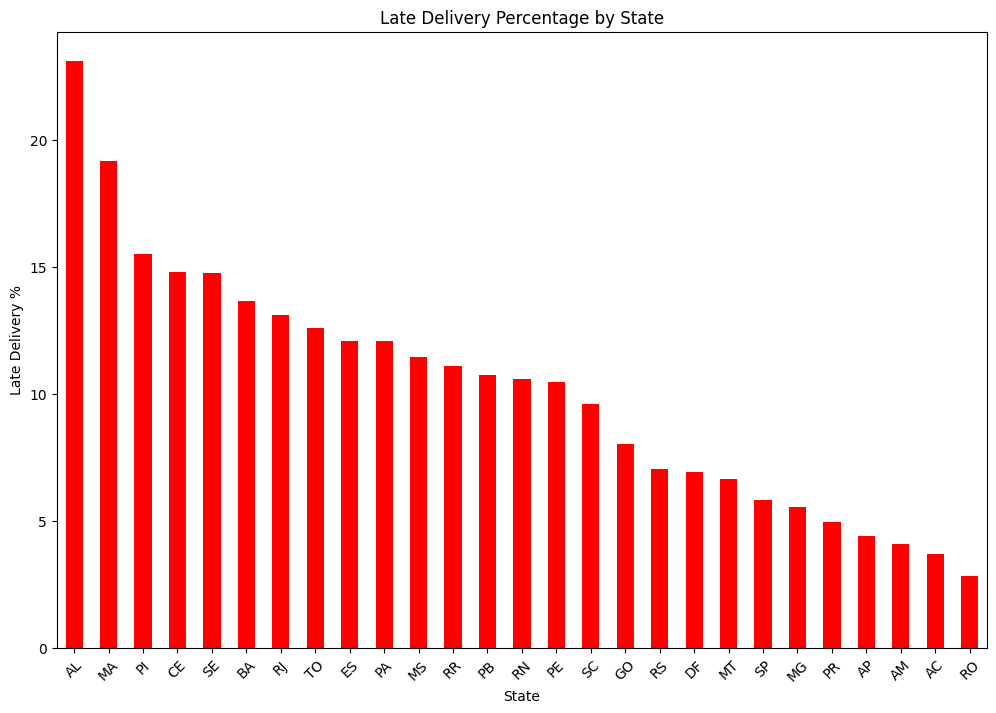


Worst performing state: AL with 23.1% late deliveries


In [21]:
# A simple bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
state_stats['Late_Percentage'].plot(kind='bar', color='red')
plt.title('Late Delivery Percentage by State')
plt.xlabel('State')
plt.ylabel('Late Delivery %')
plt.xticks(rotation=45)
plt.show()

print(f"\nWorst performing state: {state_stats.index[0]} with {state_stats.iloc[0]['Late_Percentage']:.1f}% late deliveries")


# Story 4: The Sentiment Correlation

In [22]:
# Prove that late deliveries cause bad reviews

# Filter orders that have review scores
orders_with_reviews = delivered_orders[delivered_orders['review_score'].notna()]

print("Orders with reviews:", len(orders_with_reviews))
print("Average review score overall:", orders_with_reviews['review_score'].mean().round(2))


Orders with reviews: 97473
Average review score overall: 4.12


In [23]:
# Compare average review scores by delivery status
review_by_status = orders_with_reviews.groupby('Delivery_Status')['review_score'].mean()

print("Average review score by delivery status:")
print(review_by_status.round(2))


Average review score by delivery status:
Delivery_Status
Late          3.60
On Time       4.25
Super Late    1.86
Name: review_score, dtype: float64


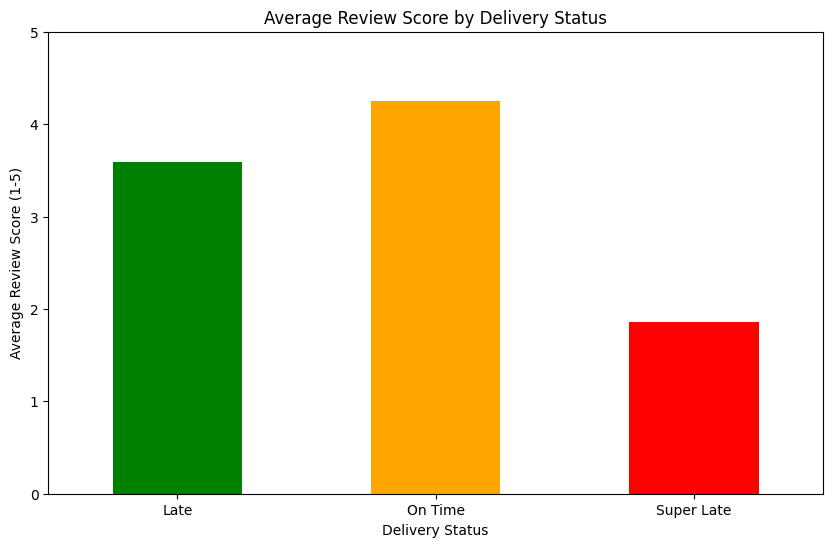

In [24]:
# Create a simple bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
review_by_status.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score (1-5)')
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.show()


In [25]:
# Show the proof with numbers
on_time_score = review_by_status['On Time']
late_score = review_by_status['Late']
super_late_score = review_by_status['Super Late']

print("THE PROOF:")
print(f"On Time orders: {on_time_score:.2f} stars")
print(f"Late orders: {late_score:.2f} stars")
print(f"Super Late orders: {super_late_score:.2f} stars")
print()
print(f"Difference between On Time and Late: {on_time_score - late_score:.2f} stars")
print(f"Difference between On Time and Super Late: {on_time_score - super_late_score:.2f} stars")


THE PROOF:
On Time orders: 4.25 stars
Late orders: 3.60 stars
Super Late orders: 1.86 stars

Difference between On Time and Late: 0.65 stars
Difference between On Time and Super Late: 2.39 stars


In [27]:
# Count how many orders in each category
status_counts = orders_with_reviews['Delivery_Status'].value_counts()

print("Number of orders in each category:")
print(status_counts)
print()
print("Percentage breakdown:")
print((status_counts / status_counts.sum() * 100).round(1))


Number of orders in each category:
Delivery_Status
On Time       89812
Super Late     4529
Late           3132
Name: count, dtype: int64

Percentage breakdown:
Delivery_Status
On Time       92.1
Super Late     4.6
Late           3.2
Name: count, dtype: float64


# Bonus Story: The Translation Challenge

In [29]:
# Translate Portuguese product categories to English

translations = pd.read_csv("product_category_name_translation.csv")


print("Number of translations:", len(translations))
print("\nSample translations:")
print(translations.head())

Number of translations: 71

Sample translations:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


In [36]:
# Load products and order items
products = pd.read_csv("olist_products_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")

print("Products loaded:", len(products))
print("Order items loaded:", len(order_items))
print(products.head())

Products loaded: 32951
Order items loaded: 112650
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               1

In [37]:
# Connect order items with product categories
order_products = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

print("Orders with product categories:", len(order_products))
print("\nTop Portuguese categories:")
print(order_products['product_category_name'].value_counts().head())
print(order_products.head())

Orders with product categories: 112650

Top Portuguese categories:
product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
Name: count, dtype: int64
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089

In [39]:
#Translate categories to English
order_products_english = order_products.merge(translations, on='product_category_name', how='left')

print("Top English categories:")
print(order_products_english['product_category_name_english'].value_counts().head(10))
print(order_products_english.head())

Top English categories:
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f

In [40]:
# Add categories to master dataset
master_with_categories = master.merge(order_products_english[['order_id', 'product_category_name_english']], on='order_id', how='left')

print("Master dataset now has product categories!")
print("Orders with categories:", master_with_categories['product_category_name_english'].notna().sum())


Master dataset now has product categories!
Orders with categories: 111023


In [51]:
# Analyze delivery performance by product category
# Filter delivered orders with categories
delivered_with_categories = master_with_categories[
    (master_with_categories['Delivery_Status'].isin(['On Time', 'Late', 'Super Late'])) &
    (master_with_categories['product_category_name_english'].notna())
]

print("Orders for analysis:", len(delivered_with_categories))
# Keep only one row per order
master_with_categories = master_with_categories.drop_duplicates(subset=['order_id'])
print("After removing duplicates:", len(master_with_categories))


Orders for analysis: 96778
After removing duplicates: 99441


In [52]:
# Analyze delivery performance by product category
# Filter delivered orders with categories
delivered_with_categories = master_with_categories[
    (master_with_categories['Delivery_Status'].isin(['On Time', 'Late', 'Super Late'])) &
    (master_with_categories['product_category_name_english'].notna())
]

print("Orders for analysis:", len(delivered_with_categories))


Orders for analysis: 96778


In [53]:
# Calculate late delivery rate by product category
category_performance = delivered_with_categories.groupby('product_category_name_english').agg({
    'order_id': 'count',
    'Delivery_Status': lambda x: (x.isin(['Late', 'Super Late'])).sum()
}).rename(columns={'order_id': 'Total_Orders', 'Delivery_Status': 'Late_Orders'})

category_performance['Late_Percentage'] = (category_performance['Late_Orders'] / category_performance['Total_Orders']) * 100
category_performance = category_performance.sort_values('Late_Percentage', ascending=False)

print("Product categories by late delivery rate:")
print(category_performance.head(10))


Product categories by late delivery rate:
                                   Total_Orders  Late_Orders  Late_Percentage
product_category_name_english                                                
home_comfort_2                               22            4        18.181818
furniture_mattress_and_upholstery            38            5        13.157895
audio                                       345           45        13.043478
fashion_underwear_beach                     121           15        12.396694
books_technical                             259           28        10.810811
home_confort                                375           38        10.133333
food                                        443           44         9.932280
electronics                                2533          247         9.751283
christmas_supplies                          127           12         9.448819
baby                                       2822          258         9.142452
